# Lab: Riemann Sums

Math 140H, Honors Calculus I

In class we approximated the area under a curve by rectangles. This notebook lets you build those rectangles, look at them, and watch the Riemann sums approach the integral as the partition gets finer.

How to use this notebook
- Cells marked IN CLASS are the core we will do together.
- Cells marked HOMEWORK extend the same ideas further.
- Cells marked PREDICT ask you to write down a guess before running the next code cell. Do not skip these; the point is to notice when your intuition is wrong.


**START BY RUNNNING THE NEXT CELL**, this will load the necessary libraries and define all Python functions needed.

In [ ]:
#| code-fold: true


#
#
# ALWAYS RUN THIS CELL FIRST!!
#
#

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Math

plt.rcParams['figure.figsize'] = (8, 4.5)
x = sp.Symbol('x')

_METHODS = {
    'left': 'left', 'l': 'left', 'lefthand': 'left', 'left-hand': 'left',
    'right': 'right', 'r': 'right', 'righthand': 'right', 'right-hand': 'right',
    'midpoint': 'midpoint', 'mid': 'midpoint', 'm': 'midpoint', 'middle': 'midpoint',
}


def _to_exact(v):
    """Turn a number into an exact sympy number (0.25 -> 1/4, pi stays pi)."""
    v = sp.sympify(v)
    if isinstance(v, sp.Float):
        v = sp.nsimplify(v, rational=True)
    return v


def _fmt(v, digits=6):
    """Format a float compactly, e.g. 0.0625, 1.41421, -3.2e-05."""
    s = f'{float(v):.{digits}g}'
    if 'e' in s:
        mant, ex = s.split('e')
        s = rf'{mant} \cdot 10^{{{int(ex)}}}'
    return s


def _join_terms(terms, n, max_terms):
    """Join LaTeX terms with + and - signs; if n is large, abbreviate with + ... +."""
    if n > max_terms:
        terms = terms[:3] + [r'\cdots'] + terms[-2:]
    out = terms[0]
    for t in terms[1:]:
        if t.startswith('-'):
            out += ' - ' + t[1:].lstrip()
        else:
            out += ' + ' + t
    return out


def riemann_sum(f, a, b, n, method='left', x=None, show=True,
                show_integral=False, max_terms=6):
    """
    Compute (and by default draw) a Riemann sum for f on [a, b].

    Parameters
    ----------
    f : sympy expression in one variable, e.g. x**2 or sp.sin(x)
    a, b : the integration bounds, a < b (numbers or sympy numbers like sp.pi)
    n : number of subintervals of equal length
    method : 'left', 'right', or 'midpoint'
    x : the variable of f (only needed if f has more than one symbol)
    show : if False, just return the value (no picture, no computation lines)
    show_integral : also display the exact integral and the error of the sum
    max_terms : largest n for which every term of the sum is written out;
                for larger n the sum is abbreviated with "+ ... +"

    Returns
    -------
    The value of the Riemann sum as a float.
    """
    # ---- check and prepare the input ----------------------------------
    method = _METHODS.get(str(method).lower().replace(' ', ''))
    if method is None:
        raise ValueError("method must be 'left', 'right', or 'midpoint'")
    n = int(n)
    if n < 1:
        raise ValueError('n must be a positive integer')
    f = sp.sympify(f)
    if x is None:
        syms = sorted(f.free_symbols, key=str)
        if len(syms) > 1:
            raise ValueError(f'f has several symbols {syms}; pass the variable as x=...')
        x = syms[0] if syms else sp.Symbol('x')
    a, b = _to_exact(a), _to_exact(b)
    if not (sp.N(a) < sp.N(b)):
        raise ValueError('need a < b')

    # ---- the partition and the sample points ---------------------------
    delta = (b - a) / n                    # exact length of each subinterval
    shift = {'left': 0, 'right': 1, 'midpoint': sp.Rational(1, 2)}[method]
    offset = {'left': 1, 'right': 0, 'midpoint': sp.Rational(1, 2)}[method]
    # sample point x_i^* = a + (i - offset) * delta, for i = 1, ..., n

    f_num = sp.lambdify(x, f, 'numpy')
    a_f, b_f, d_f = float(a), float(b), float(delta)
    left_edges = a_f + d_f * np.arange(n)
    samples = left_edges + float(shift) * d_f
    with np.errstate(all='ignore'):
        heights = np.broadcast_to(np.asarray(f_num(samples), dtype=float), samples.shape)
    if not np.all(np.isfinite(heights)):
        bad = samples[~np.isfinite(heights)][0]
        raise ValueError(f'f is not defined (or infinite) at the sample point {bad:g}; '
                         'try a different method or interval')
    value = float(np.sum(heights) * d_f)
    if abs(value) < 1e-12 * max(1.0, float(np.sum(np.abs(heights)) * d_f)):
        value = 0.0          # the exact answer is 0; the rest is rounding noise

    if not show:
        return value

    # ---- the picture ---------------------------------------------------
    fig, ax = plt.subplots()
    colors = np.where(heights >= 0, 'tab:blue', 'tab:red')
    edge = 'black' if n <= 100 else 'none'
    ax.bar(left_edges, heights, width=d_f, align='edge', color=colors,
           alpha=0.35, edgecolor=edge, linewidth=0.8)
    xs = np.linspace(a_f, b_f, 1000)
    with np.errstate(all='ignore'):
        ys = np.array(np.broadcast_to(np.asarray(f_num(xs), dtype=float), xs.shape))
    ys[~np.isfinite(ys)] = np.nan
    ax.plot(xs, ys, color='black', linewidth=2, label=f'$f({x}) = {sp.latex(f)}$')
    if n <= 60:
        ax.plot(samples, heights, 'o', color='darkorange', markersize=5,
                label=r'$(x_i^*, f(x_i^*))$')
    ax.axhline(0, color='gray', linewidth=0.8)
    pad = 0.05 * (b_f - a_f)
    ax.set_xlim(a_f - pad, b_f + pad)
    # if f blows up somewhere, keep the rectangles in view instead of the spike
    h_lo, h_hi = min(0.0, heights.min()), max(0.0, heights.max())
    span = h_hi - h_lo
    y_lo, y_hi = np.nanmin(ys), np.nanmax(ys)
    if span > 0 and (y_hi > h_hi + 2 * span or y_lo < h_lo - 2 * span):
        lo, hi = max(y_lo, h_lo - 0.5 * span), min(y_hi, h_hi + 0.5 * span)
        ax.set_ylim(min(lo, h_lo) - 0.05 * span, max(hi, h_hi) + 0.05 * span)
    ax.set_xlabel(f'${x}$')
    ax.set_title(f'{method.capitalize()} Riemann sum with n = {n}')
    handles, labels = ax.get_legend_handles_labels()
    if np.any(heights < 0):
        handles += [Patch(color='tab:blue', alpha=0.35), Patch(color='tab:red', alpha=0.35)]
        labels += [r'$f(x_i^*) \geq 0$', r'$f(x_i^*) < 0$']
    ax.legend(handles, labels, loc='best')
    ax.grid(True, alpha=0.3)
    plt.show()

    # ---- the computation, line by line ----------------------------------
    A, B, D = sp.latex(a), sp.latex(b), sp.latex(delta)
    fx = sp.latex(f)
    sample_rule = {
        'left':     r'x_i^* = x_{i-1} = a + (i-1)\Delta',
        'right':    r'x_i^* = x_i = a + i\,\Delta',
        'midpoint': r'x_i^* = \frac{x_{i-1} + x_i}{2} = a + \left(i - \tfrac{1}{2}\right)\Delta',
    }[method]

    display(Math(rf'f({x}) = {fx}, \qquad [a, b] = [{A}, {B}], \qquad n = {n}'))
    a_paren = rf'\left({A}\right)' if sp.N(a) < 0 else A
    display(Math(rf'\Delta = \frac{{b-a}}{{n}} = \frac{{{B} - {a_paren}}}{{{n}}} = {D}'
                 + (rf' \approx {_fmt(d_f)}' if not delta.is_Rational else '')
                 + rf', \qquad x_i = a + i\,\Delta \quad (i = 0, 1, \ldots, {n})'))
    display(Math(rf'\text{{{method} sample points: }} {sample_rule}'))

    # which indices get written out
    idx = list(range(1, n + 1)) if n <= max_terms else [1, 2, 3, n - 1, n]
    pts = [a + (i - offset) * delta for i in idx]
    pts = [sp.nsimplify(p) if p.is_Rational else sp.simplify(p) for p in pts]
    f_terms = [rf'f\!\left({sp.latex(p)}\right)' for p in pts]
    vals = [sp.nsimplify(sp.simplify(f.subs(x, p))) for p in pts]
    if all(v.is_Rational and len(sp.latex(v)) <= 14 for v in vals):
        val_terms = [sp.latex(v) for v in vals]
    else:
        val_terms = [_fmt(sp.N(v)) for v in vals]

    general = rf'RS(P, S) = \sum_{{i=1}}^{{{n}}} f(x_i^*)\,\Delta'
    display(Math(general + rf' = \Delta \left[ f(x_1^*) + f(x_2^*) + \cdots + f(x_{{{n}}}^*) \right]'))
    display(Math(rf'\phantom{{RS(P, S)}} = {D} \left[ {_join_terms(f_terms, n, max_terms)} \right]'))
    display(Math(rf'\phantom{{RS(P, S)}} = {D} \left[ {_join_terms(val_terms, n, max_terms)} \right]'))

    # exact value when it is a short rational number, else a decimal
    exact = None
    if n <= 200:
        total = sp.nsimplify(sum(f.subs(x, a + (i - offset) * delta) for i in range(1, n + 1)) * delta)
        if total.is_Rational and len(sp.latex(total)) <= 20:
            exact = total
    if exact is not None and exact.q != 1:
        result = rf'{sp.latex(exact)} \approx {_fmt(value, 10)}'
    else:
        result = _fmt(value, 10)
    display(Math(rf'\phantom{{RS(P, S)}} = \mathbf{{{result}}}'))

    if show_integral:
        I = sp.integrate(f, (x, a, b))
        I_num = float(sp.N(I))
        if isinstance(I, sp.Integral):   # no closed form found
            display(Math(rf'\int_{{{A}}}^{{{B}}} {fx}\, d{x} \approx {_fmt(I_num, 10)}'))
        else:
            approx = '' if I.is_Rational else rf' \approx {_fmt(I_num, 10)}'
            display(Math(rf'\int_{{{A}}}^{{{B}}} {fx}\, d{x} = {sp.latex(I)}' + approx))
        err = value - I_num
        err_tex = '0' if abs(err) < 1e-12 else _fmt(err, 4)
        display(Math(rf'\text{{error: }} RS(P, S) - \int_{{{A}}}^{{{B}}} f\,d{x} \approx {err_tex}'))

    return value

## Recap: the setup from lecture

Let $f : [a,b] \to \mathbb{R}$.

- A partition $P$ of $[a,b]$ is a choice of points $a = x_0 < x_1 < \cdots < x_n = b$.
- $\Delta_i = x_i - x_{i-1}$ is the length of the $i$-th segment $[x_{i-1}, x_i]$.
- Sample points $S = \{x_1^*, \ldots, x_n^*\}$ with $x_i^* \in [x_{i-1}, x_i]$ determine the heights $f(x_i^*)$ of the rectangles.
- The Riemann sum is
$$RS(P,S) = f(x_1^*)\,\Delta_1 + \cdots + f(x_n^*)\,\Delta_n = \sum_{i=1}^n f(x_i^*)\,\Delta_i.$$

In this notebook we always split $[a,b]$ into $n$ segments of equal length, so $\Delta_i = \Delta = \frac{b-a}{n}$ and $x_i = a + i\Delta$. There are three standard ways to pick the sample points:

| method | sample point in $[x_{i-1}, x_i]$ |
|---|---|
| `'left'` | $x_i^* = x_{i-1}$, the left endpoint |
| `'right'` | $x_i^* = x_i$, the right endpoint |
| `'midpoint'` | $x_i^* = \frac{x_{i-1}+x_i}{2}$, the midpoint |

Run the next cell to define the function `riemann_sum`. You do not need to read its code to use it.

### How to call `riemann_sum`

```python
riemann_sum(f, a, b, n, method)
```

- `f` is an expression in `x`, for example `x**2`, `sp.sin(x)`, `sp.exp(-x**2)`, `1/x`, `sp.sqrt(1 - x**2)` (Recall: exponentiation in Python is `**`. The prefix `sp.` instructs python to use a library for symbolic computation called `sympy`.)
- `a`, `b` are the bounds with `a < b`; exact values like `sp.pi` or `sp.Rational(1, 3)` are fine
- `n` is the number of subintervals
- `method` is `'left'`, `'right'`, or `'midpoint'`

Optional arguments:
- `show_integral=True` also displays the exact integral and the error of the Riemann sum
- `show=False` skips the picture and just returns the number (useful in loops)
- `max_terms=6` controls how many terms are written out before the sum is abbreviated with $+ \cdots +$

The function returns the value of the sum. End the line with a semicolon `;` so Jupyter does not print that number a second time.

## Part 1: Start

We start with $f(x) = x$ on $[1,2]$ and $n = 5$ subintervals.

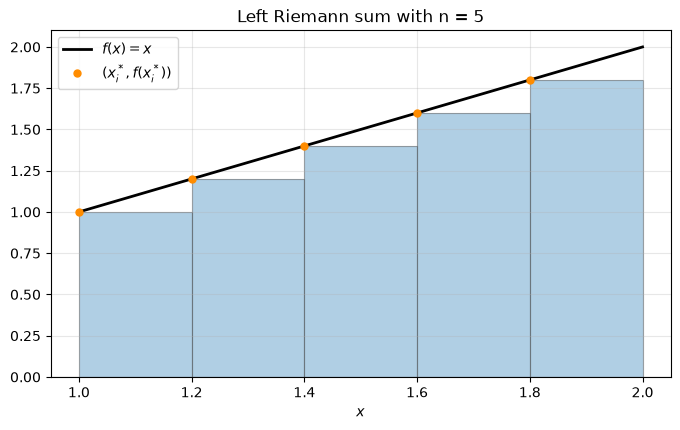

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [2]:
riemann_sum(x, 1, 2, 5, 'left');

In class, we computed the actual value of the integral $\int_a^b x dx$. How does this value compare? Increase `n` in the cell above and see what happens.

## Part 2: Left, right, and midpoint sums

Now we look at the function $f(x) = x^2$ on $[0,1]$ and $n = 4$ subintervals.

**PREDICT** (on paper, before running anything):
- Will the left sum overestimate or underestimate the area under $x^2$? What about the right sum?
- Compute the left sum by hand. You should need nothing more than adding four fractions.

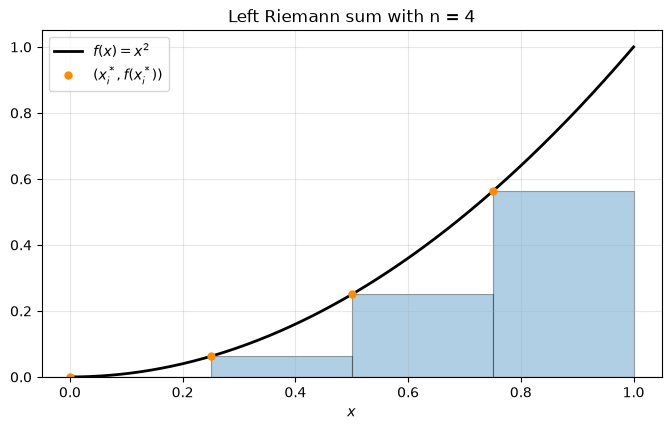

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
riemann_sum(x**2, 0, 1, 4, 'left');

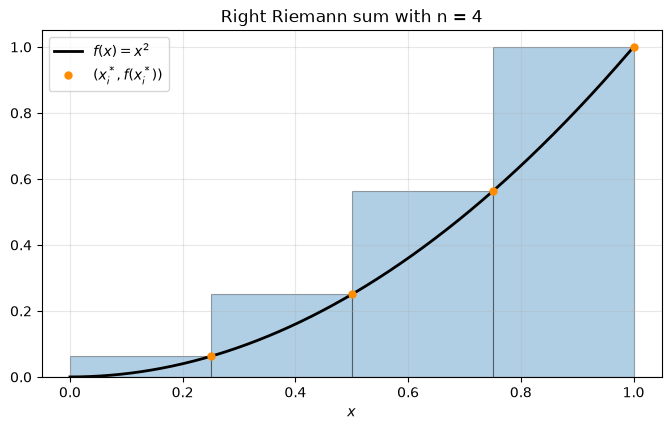

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
riemann_sum(x**2, 0, 1, 4, 'right');

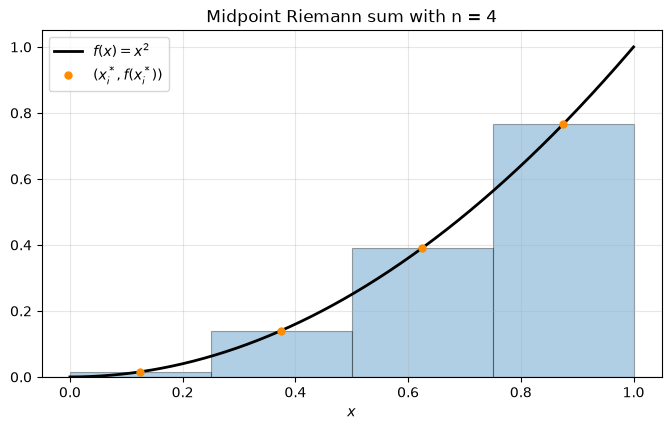

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
riemann_sum(x**2, 0, 1, 4, 'midpoint', show_integral=True);

**VERIFY:** The left and right sums share almost all of their terms. Show that for any $f$ and equally spaced partition,
$$RS_{\text{right}} - RS_{\text{left}} = \Delta\,\bigl(f(b) - f(a)\bigr),$$
and check this against the two numbers you just computed.

**REFLECT:** Your prediction about over- and underestimates depended on a property of $x^2$ on $[0,1]$. Which property? State a general claim about left and right sums for functions with that property.

## Part 3: Refining the partition

In lecture, the approximation got better by refining the partition. Let us watch that happen. Once $n$ is larger than 6, the written-out sum is abbreviated with $+ \cdots +$.

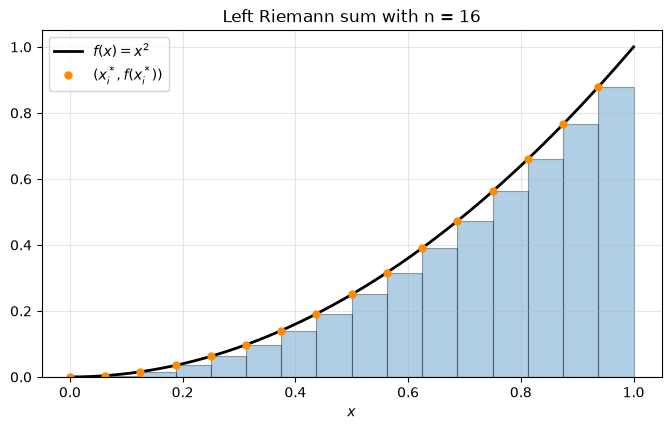

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
riemann_sum(x**2, 0, 1, 16, 'left', show_integral=True);

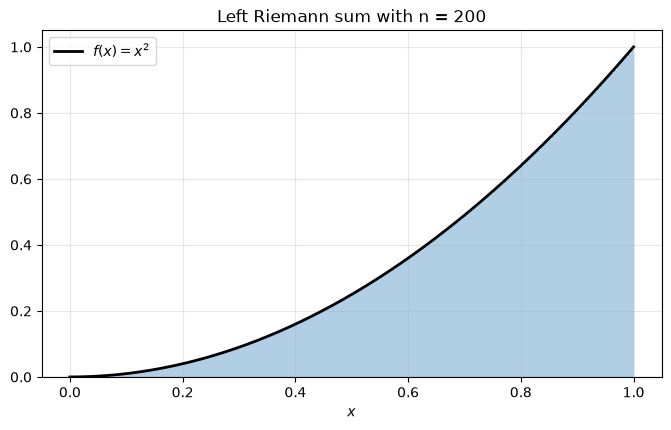

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
riemann_sum(x**2, 0, 1, 200, 'left', show_integral=True);

## Part 4: Back to the circle

We started the Riemann integral lecture by approximating the area $\pi$ of the unit circle with regular $n$-gons. The quarter of the unit disk in the first quadrant is the region under $f(x) = \sqrt{1 - x^2}$ on $[0,1]$, so $4\int_0^1 \sqrt{1-x^2}\,dx = \pi$.

**PREDICT:** Is the left sum of $\sqrt{1-x^2}$ on $[0,1]$ an overestimate or an underestimate? Why?

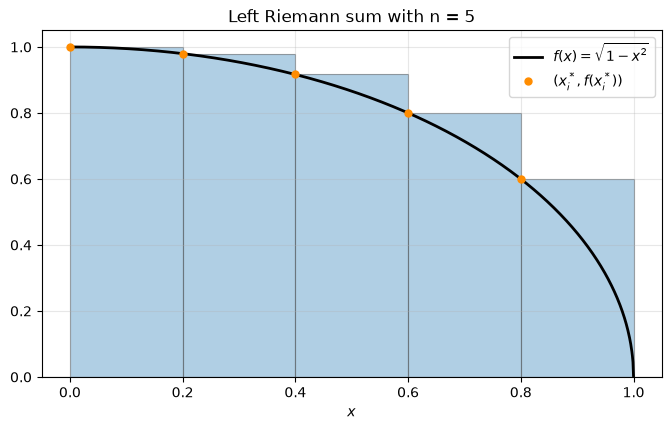

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
riemann_sum(sp.sqrt(1 - x**2), 0, 1, 5, 'left', show_integral=True);

# TODO: find the smallest n for which 4 * (left sum) is within 10**(-3) of pi.
#   Use riemann_sum(..., show=False) inside a loop.
# TODO: do the same for the midpoint sum. How much smaller is the n you need?

## Part 5: Experiment on your own

Change the function, bounds, $n$, and method in the cell below and run it again. If `ipywidgets` is installed, the cell after it gives you sliders instead.

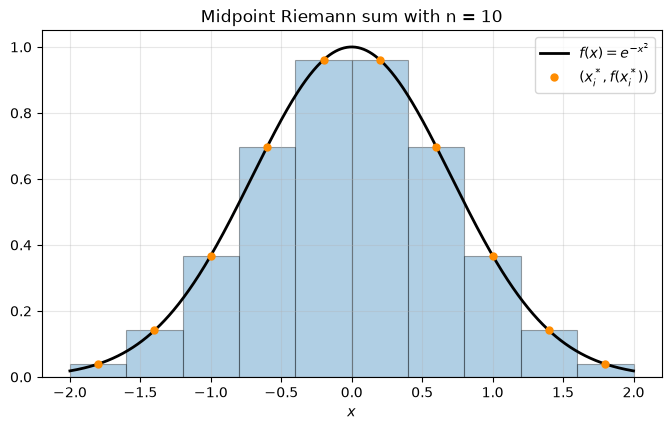

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
f = sp.exp(-x**2)
riemann_sum(f, -2, 2, 10, 'midpoint', show_integral=True);

In [10]:
# Interactive version: move the slider or change the method
try:
    from ipywidgets import interact, IntSlider, Dropdown

    def explore(n=4, method='left'):
        riemann_sum(sp.sin(x) + 1.5, 0, 2*sp.pi, n, method, show_integral=True)

    interact(explore,
             n=IntSlider(min=1, max=100, step=1, value=4),
             method=Dropdown(options=['left', 'right', 'midpoint'], value='left'));
except ImportError:
    print('ipywidgets is not installed; use the cell above instead.')

interactive(children=(IntSlider(value=4, description='n', min=1), Dropdown(description='method', options=('lef…

## Part 6: when Riemann sums fail

Riemann sums are defined for bounded functions. Look at what happens for $f(x) = 1/x$ on $[0,1]$ using right sums (the left sum would need $f(0)$, which does not exist).

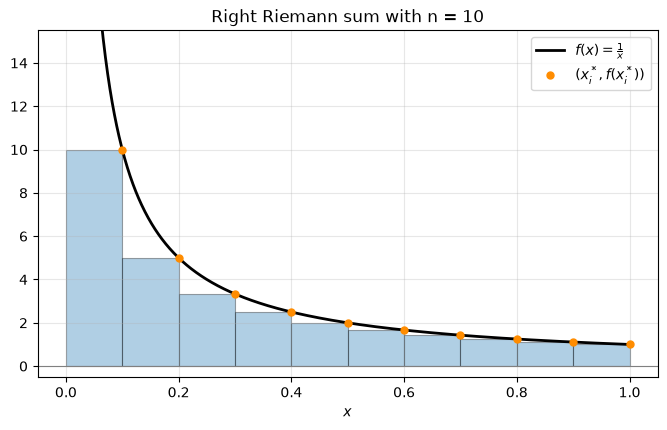

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

10 2.9289682539682538
100 5.187377517639621
1000 7.485470860550345
10000 9.78760603604438


In [11]:
riemann_sum(1/x, 0, 1, 10, 'right');

for n in [10, 100, 1000, 10000]:
    print(n, riemann_sum(1/x, 0, 1, n, 'right', show=False))

# TODO: what happens to the sums as n grows? Compare with 1/sp.sqrt(x) on [0, 1].
#   The first rectangle is always very tall in both cases, 
#    so why do the two behave so differently?